In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn

train_df = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/train.csv")
test_df = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/test.csv")

train_df

,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?
...,...,...,...
5447,1,14,What 's the shape of a camel 's spine ?
5448,1,46,What type of currency is used in China ?
5449,4,41,What is the temperature today ?
5450,4,41,What is the temperature for cooking ?


In [2]:
from custom_tokenizer import BytePairEncodingTokenizer

# load tokenizer
tokenizer = BytePairEncodingTokenizer()
tokenizer.load_tokenizer('tokenizer.pkl')

In [3]:
import re
import contractions as con
from string import punctuation


def preprocess_text(x, tweet=False):
    """
    Text preprocessing rules:
    - lowercase everything
    - replace ALL string.punctuation with space-surrounded tokens
      e.g. "!" -> " ! ", "???" -> " ? ? ? "
    - replace twitter users with USER
    - replace URLs with LINK
    - replace emojis with EMOJI (collapse consecutive emojis into one)
    """

    # ensure string + lowercase
    x = str(x).lower()
    x = re.sub(r'[\u200d\uFE0F]', ' ', x)
    x = re.sub(r'[“”]', '"', x)
    x = re.sub(r"[‘’]", "'", x)
    x = re.sub(r'[–—−]', '-', x)
    x = re.sub(r'…', '...', x)

    # replace html entities
    x = x.replace('&amp;', 'and').replace('&quot;', '').replace('<br />', ' ')
    x = re.sub(r'&#x[0-9a-f]+;', ' ', x)
    x = re.sub(r'&#\d+;', ' ', x)

    # replace URLs
    x = re.sub(r'http\S+|www\S+', ' LINK ', x)

    # replace twitter users
    if tweet:
        x = re.sub(r'@\w+', ' USER ', x)

    # replace emojis (unicode ranges)
    emoji_pattern = re.compile(
        r'('
        r'[\U0001F1E6-\U0001F1FF]{2}|'              # flags
        r'[\U0001F600-\U0001F64F]|'                # emoticons
        r'[\U0001F300-\U0001F5FF]|'                # symbols
        r'[\U0001F680-\U0001F6FF]|'                # transport
        r'[\U0001F700-\U0001F77F]|'
        r'[\U0001F780-\U0001F7FF]|'
        r'[\U0001F800-\U0001F8FF]|'
        r'[\U0001F900-\U0001F9FF]|'
        r'[\U0001FA00-\U0001FAFF]|'
        r'[\u2600-\u26FF]|'
        r'[\u2700-\u27BF]'
        r')+',
        flags=re.UNICODE
    )
    x = emoji_pattern.sub(' EMOJI ', x)

    # collapse multiple EMOJI tokens into one
    x = re.sub(r'(EMOJI\s+)+', ' EMOJI ', x)

    # replace each punctuation with space-surrounded version
    for p in punctuation:
        x = x.replace(p, f' {p} ')

    # normalize whitespace
    x = re.sub(r'\s+', ' ', x).strip()

    return x

In [4]:
from tqdm.auto import tqdm

X = train_df.text.values
Y = train_df['label-coarse'].values

X = [preprocess_text(x) for x in tqdm(X)]
X = [tokenizer.tokenize(x) for x in tqdm(X)]

tokenizer.maxlen = max([len(x) for x in X])

X = np.array([tokenizer.add_padding(x) for x in tqdm(X)],np.int16)

  0%|          | 0/5452 [00:00<?, ?it/s]

  0%|          | 0/5452 [00:00<?, ?it/s]

  0%|          | 0/5452 [00:00<?, ?it/s]

In [5]:
xtest = test_df.text.values
ytest = test_df['label-coarse'].values

xtest = [preprocess_text(x) for x in tqdm(xtest)]
xtest = [tokenizer.tokenize(x) for x in tqdm(xtest)]

xtest = np.array([tokenizer.add_padding(x) for x in tqdm(xtest)],np.int16)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [6]:
for i in range(20):
    
    print(' '.join([tokenizer.i2w[t] for t in X[i] if t>0]))
    print()

<cls> ##how ##did ##ser f dom ##develop ##in ##and ##then ##leave ##russia ? <sep>

<cls> ##what ##films ##featured ##the ##character ##pop eye ##do yl e ? <sep>

<cls> ##how ##can ##i ##find ##a ##list ##of ##celebr ities ' ##real ##names ? <sep>

<cls> ##what ##f ow l ##grab s ##the ##spot light ##after ##the ##chinese ##year ##of ##the ##mon key ? <sep>

<cls> ##what ##is ##the ##full ##form ##of . ##com ? <sep>

<cls> ##what ##cont emp tible ##sc ound rel ##sto le ##the ##cor k ##from ##my ##lunch ? <sep>

<cls> ##what ##team ##did ##baseball ' ##s ##st . ##louis ##brown s ##become ? <sep>

<cls> ##what ##is ##the ##old est ##profession ? <sep>

<cls> ##what ##are ##liver ##en zy mes ? <sep>

<cls> ##name ##the ##scar - ##faced ##boun ty ##hunt er ##of ##the ##old ##west . <sep>

<cls> ##when ##was ##o zz y ##os bou r ne ##born ? <sep>

<cls> ##why ##do ##heavi er ##objects ##travel ##down hill ##faster ? <sep>

<cls> ##who ##was ##the ##pride ##of ##the ##yan ke es ? <sep>

<cls> 

In [7]:
from sklearn.model_selection import train_test_split

# xtrain,xval,ytrain,yval = train_test_split(X,Y,train_size=0.9,random_state=0)


In [8]:
MAXLEN = tokenizer.maxlen
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 3
FF_UNITS = D_MODEL * 3
PEAK_LR = 2e-4
END_LR = 1e-8
INIT_LR = 1e-8
WARMUP_RATE = 0.05
BATCH = 8
EMB_DIM = 128
VOCAB_SIZE = len(tokenizer.i2w)

In [9]:
from model import RobustNet
from torchinfo import summary

model = RobustNet(D_MODEL,N_HEADS,N_LAYERS,VOCAB_SIZE,128)

i1 = torch.randint(0,VOCAB_SIZE,(BATCH,128))
i2 = torch.randint(0,VOCAB_SIZE,(BATCH,128 - 1))

print(summary(model,input_data=(i1,i2)))

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except:
    device = torch.device('cpu')
    
model = model.to(device)

model.load_state_dict(torch.load('best_weights.pt',map_location=device))

Layer (type:depth-idx)                   Output Shape              Param #
RobustNet                                [8, 127, 15039]           --
├─FactorizeEmbeddingLayer: 1-1           [8, 128, 256]             --
│    └─Embedding: 2-1                    [8, 128, 128]             1,924,992
│    └─Linear: 2-2                       [8, 128, 256]             33,024
├─FactorizeEmbeddingLayer: 1-2           [8, 127, 256]             (recursive)
│    └─Embedding: 2-3                    [8, 127, 128]             (recursive)
│    └─Linear: 2-4                       [8, 127, 256]             (recursive)
├─EncoderLayer: 1-3                      [8, 128, 256]             --
│    └─MultiHeadAttention: 2-5           [8, 128, 256]             --
│    │    └─Linear: 3-1                  [8, 128, 256]             65,536
│    │    └─Linear: 3-2                  [8, 128, 256]             65,536
│    │    └─Linear: 3-3                  [8, 128, 256]             65,536
│    │    └─Dropout: 3-4           

/home/bibek/pytorch_env/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


<All keys matched successfully>

In [10]:
def _positional_encoding(maxlen,d_model):
    pos = np.zeros((maxlen, d_model), dtype=np.float32)
    for p in range(maxlen):
        for i in range(d_model):
            if i % 2 == 0:
                angle = p / 10000 ** (2 * i / d_model)
                pos[p, i] = np.sin(angle)
            else:
                angle = p / 10000 ** (2 * i / d_model)
                pos[p, i] = np.cos(angle)
    return torch.tensor(pos,dtype=torch.float32,device=device)

In [11]:
new_pe = _positional_encoding(MAXLEN,D_MODEL)
new_pe = nn.Parameter(new_pe,requires_grad=False)
model.fact_emb_layer.pos_encoding = new_pe

In [12]:
fact_emb_layer = model.fact_emb_layer
encoder_layer = model.encoder_layer
scaler_layer = model.scaler_layer



In [13]:
class CustomPool(nn.Module):
    
    def __init__(self,maxlen):
        super().__init__()
        
        self.w = nn.Parameter(torch.empty(1,maxlen),requires_grad=True)
        nn.init.constant_(self.w,1/maxlen)
        self.score = None
    
    def forward(self,x,mask):
        
        mask = torch.where(mask,-1e8,self.w)
        mask = torch.softmax(mask,-1).unsqueeze(-1)
        x = x * mask
        self.score = mask
        return x.sum(1)

In [14]:
import os, random


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)

In [15]:
class Classifier(nn.Module):
    
    def __init__(self,dim,n_classes,maxlen):
        super().__init__()
        self.emb = fact_emb_layer
        self.enc = encoder_layer
        self.scaler = scaler_layer
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out = nn.Linear(dim,n_classes)
        self.lin = nn.Linear(dim,dim//4)
        self.drop = nn.Dropout(0.1)
        self.pool_ = CustomPool(maxlen)
        
    def forward(self,i):
        
        x,mask = self.emb(i)
        
        x = self.enc([x,mask])
        x = self.scaler[0](x)
        
        x = self.enc([x,mask])
        x = self.scaler[1](x)
        
        x = self.enc([x,mask])
        x = self.scaler[2](x)
        
#         x = self.lin(x)
#         x = nn.functional.leaky_relu(x)
#         x = self.drop(x)
        
#         x = x.transpose(2,1)
#         x = self.pool(x).squeeze(-1)
        
        x = self.pool_(x,mask=mask)
        
        x = self.drop(x)
        
        x = self.out(x)
        
        return x

    
reset_random_seeds()
    
N_CLASSES = len(np.unique(Y))
    
model = Classifier(D_MODEL,N_CLASSES,MAXLEN)

device = torch.device("cpu")
model = model.to(device)

inp = torch.randint(0,VOCAB_SIZE,(BATCH,MAXLEN))
print(summary(model,input_data=inp))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [8, 6]                    16,448
├─FactorizeEmbeddingLayer: 1-1           [8, 46, 256]              11,776
│    └─Embedding: 2-1                    [8, 46, 128]              1,924,992
│    └─Linear: 2-2                       [8, 46, 256]              33,024
├─EncoderLayer: 1-2                      [8, 46, 256]              --
│    └─MultiHeadAttention: 2-3           [8, 46, 256]              --
│    │    └─Linear: 3-1                  [8, 46, 256]              65,536
│    │    └─Linear: 3-2                  [8, 46, 256]              65,536
│    │    └─Linear: 3-3                  [8, 46, 256]              65,536
│    │    └─Dropout: 3-4                 [8, 8, 46, 46]            --
│    │    └─Linear: 3-5                  [8, 46, 256]              65,792
│    │    └─Dropout: 3-6                 [8, 46, 256]              --
│    └─LayerNorm: 2-4                    [8, 46, 2

In [16]:
from torch.utils.data import TensorDataset, DataLoader

def create_tensor_data(x,y,batch,shuffle=True):
    
    x_ = torch.tensor(x,dtype=torch.int32,device=device)
    y_ = torch.tensor(y,dtype=torch.int32,device=device)
    data = TensorDataset(x_,y_)
    data = DataLoader(data,batch_size=batch,shuffle=shuffle)
    return data

train = create_tensor_data(X,Y,BATCH)
# valid = create_tensor_data(xval,yval,BATCH * 2,shuffle=False)
test = create_tensor_data(xtest,ytest,BATCH * 2,shuffle=False)

opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()

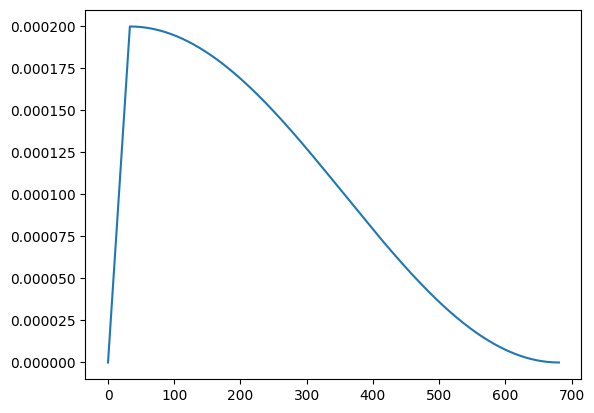

In [17]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

lr_scheduler = CosineLRScheduler(len(train),peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,len(train)+1)])

In [18]:
from tqdm.auto import tqdm

EPOCHS = 10

losses = {'train':[],'valid':[]}

for e in range(1,EPOCHS + 1):
    
    print(f"{e}/{EPOCHS}")
    
    loss = 0
    model.train()
    
    for i,batch in enumerate(tqdm(train),1):
        
        lr = lr_scheduler(i)
        opt.param_groups[0]['lr'] = lr
        
        opt.zero_grad()
        
        x,y = batch
        y = y.long()
        pred = model(x)
        batch_loss = loss_fn(pred,y)
        batch_loss.backward()
        opt.step()
        
        loss += batch_loss.item()
    
    loss = round(loss / len(train),4)
    losses['train'].append(loss)
    
    print(f'Train Loss = {loss}')
    
    model.eval()
    loss = 0
    
    with torch.no_grad():
        
        for i,batch in enumerate(test):
            
            x,y = batch
            y = y.long()
            pred = model(x)
            batch_loss = loss_fn(pred,y)
            loss += batch_loss.item()
            
    loss = round(loss / len(test),4)
    print(f"Val Loss = {loss}")
    
    
    if e == 1 or loss < min(losses['valid']):
        torch.save(model.state_dict(),'saved_weights.pt')
        print("--weights saved")
        
    losses['valid'].append(loss)
        
    print()

1/10


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.7989
Val Loss = 0.4693
--weights saved

2/10


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.4167
Val Loss = 0.3403
--weights saved

3/10


...

Train Loss = 0.0937
Val Loss = 0.3464

8/10


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.0704
Val Loss = 0.368

9/10


  0%|          | 0/682 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x7cbb1ff23100>
Traceback (most recent call last):
  File "/home/bibek/pytorch_env/lib/python3.12/site-packages/tqdm/std.py", line 1147, in __del__
KeyboardInterrupt: 

KeyboardInterrupt



In [19]:
state_dict = torch.load("saved_weights.pt", map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       138
           1       0.88      0.79      0.83        94
           2       1.00      0.67      0.80         9
           3       0.94      0.97      0.95        65
           4       0.98      0.93      0.95       113
           5       0.91      0.90      0.91        81

    accuracy                           0.92       500
   macro avg       0.93      0.87      0.90       500
weighted avg       0.92      0.92      0.91       500

0.8965594450834175


<Axes: >

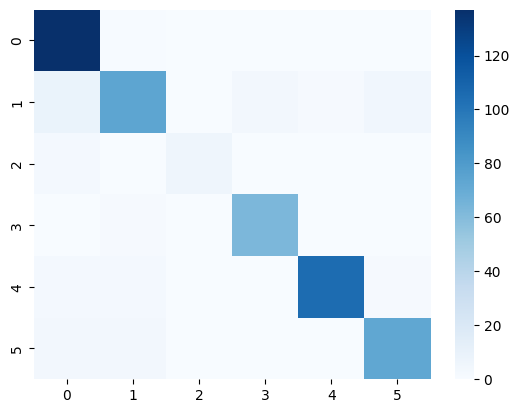

In [22]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)

print(classification_report(ytest,preds))
print(f1_score(ytest,preds,average='macro'))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues')  

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       138
           1       0.85      0.78      0.81        94
           2       1.00      0.67      0.80         9
           3       0.94      0.97      0.95        65
           4       0.97      0.92      0.95       113
           5       0.89      0.89      0.89        81

    accuracy                           0.90       500
   macro avg       0.92      0.87      0.89       500
weighted avg       0.91      0.90      0.90       500

0.8868270332187859


<Axes: >

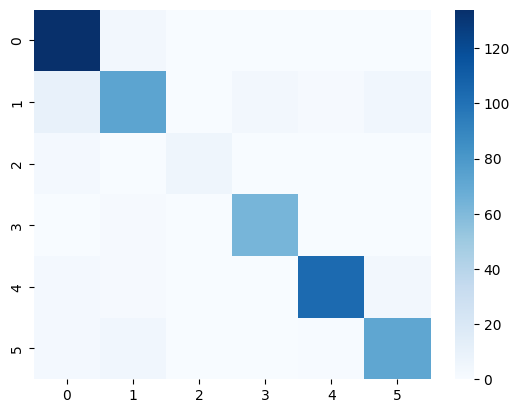

In [24]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)

print(classification_report(ytest,preds))
print(f1_score(ytest,preds,average='macro'))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues')  